# 14_train_evaluate_supervised_ML_models

Run supervised ML training/evaluation across feature combinations, split types, and model choices.

## 1) Environment Setup


In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## 2) Imports


In [2]:
from pprint import pprint
from project_config.feature_registry import COMBI_ML_FEATURE_SETS
from project_config.variables import address_dict


## 3) Optional Data Segmentation


In [3]:
from tools.ml.segment_data import run_data_segmentation

# Optional: run segmentation before ML.
segmentation_inputs = {
    'run_segmentation': False,
    'root_key': 'MUTAGENESIS-DATA-BENCHMARKS',
    'data_subfolder': 'Q65J43_BACLD_g4_Thomas_2025',
    'csv_file': 'Q65J43_BACLD_g4_Thomas_2025.csv',
    'output_csv_file': 'Q65J43_BACLD_g4_Thomas_2025_1.csv',  # optional override
    'k_folds': 5,
    'mutation_separator': ':',
    'num_mutation_segments_singlemut': 5,
    'max_layer_size_for_multimut_segmentation': [None,1000,500,250],
    'min_layer_size_for_multimut_segmentation': 1000,
    'smallest_single_mutant_size': 70,
    'include_mutation_onehot_for_clustering': True,
    'verbose': True,
}

segmentation_result = {'status': 'skipped', 'output_dataset_fname': None}
if segmentation_inputs['run_segmentation']:
    csv_dir = (repo_root / Path(address_dict[segmentation_inputs['root_key']]) / 'expdata' / segmentation_inputs['data_subfolder']).resolve()
    payload = dict(segmentation_inputs)
    payload['csv_dir'] = str(csv_dir)
    segmentation_result = run_data_segmentation(payload)

print(segmentation_result)


{'status': 'skipped', 'output_dataset_fname': None}


## 4) Configure ML Inputs


In [4]:
import agentic_protein_design.steps.train_evaluate_supervised_ml_models as ml_step
default_user_inputs = ml_step.default_user_inputs
user_inputs = default_user_inputs()

# Edit these for your run
user_inputs['root_key'] = 'MUTAGENESIS-DATA-BENCHMARKS' # 'examples' # 'ECOHARVEST' #
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'Q65J43_BACLD_g4_Thomas_2025' # 'ET096_R1-2' # 'RML_R1' #
user_inputs['csv_suffix'] = '_0' # '' #
default_dataset_fname = user_inputs['data_subfolder'] + '_1.csv'
user_inputs['dataset_fname'] = segmentation_result.get('output_dataset_fname') or default_dataset_fname

# Experimental data parent folder: address_dict[root_key] / "expdata" / data_subfolder
expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
user_inputs['input_filename_prefix'] = user_inputs['data_subfolder'] + '_' # ''
user_inputs['sequence_base'] = 'sequences/Q65J43_BACLD_g4_Thomas_2025.fasta' # "sequences/ET096.fasta"
user_inputs['target_col'] = ['DMS_score'] # [f'foldchange_{s}_activity_25C' for s in ['NBD','ABTS']] # ['foldchange_TSO'] #
user_inputs['classification_or_regression'] = 'regression'

# specify splits
user_inputs['split_type_list'] = ['custom', 'mutres-modulo', 'random'] # ['mutres-modulo', 'random'] # ['mutres-modulo', 'custom'] # ['random', 'custom'] #
user_inputs['k_folds'] = 5
user_inputs['random_kfold_repeats'] = 1  # >1 enables repeated random k-fold from scratch
user_inputs['random_split_col'] = f'fold_random_{user_inputs["k_folds"]}'
user_inputs['mutres_split_col'] = f'fold_mutres-modulo_{user_inputs["k_folds"]}'
user_inputs['contiguous_split_col'] = f'fold_contiguous_{user_inputs["k_folds"]}'  # optional precomputed column
user_inputs['custom_split_col'] = 'fold_custom'
user_inputs['custom_test_value'] = 1
user_inputs['segment_col'] = 'segment_index_1'  # which segmentation column to use
user_inputs['segment_index_range'] = [13, None] #  None  # [24, 26]; None/[]/[None, None] => full range

# specify custom dataset name
user_inputs['custom_test_dataset_fname'] = None # 'ET096_R3.csv' # ''
user_inputs['custom_test_data_subfolder'] = user_inputs['data_subfolder']
user_inputs['custom_input_filename_prefix'] = None if user_inputs['custom_test_dataset_fname'] is None else user_inputs['custom_test_dataset_fname'].split('.')[0] # ''

# specify featureset combinations to test
# user_inputs['feature_combinations_dict'] = COMBI_ML_FEATURE_SETS
user_inputs['feature_combinations_dict'] = {
    'onehot_esm2_LLR': ['one_hot', 'esm2-650m_LLR-masked'],
    'georgiev_esm2_LLR': ['georgiev', 'esm2-650m_LLR-masked'],
    'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33', 'esm2-650m_LLR-masked'],
}

# specify models
user_inputs['model_list'] =  ['ridge', 'xgboost'] # ['mlp_sklearn', 'mlp_pytorch'] #

# run parameters
# hyperparameter tuning (applied from first fold to subsequent folds in each segment)
user_inputs['hyperparameter_mode'] = 'optuna_search' # 'preset_search' # 'default', 'ntrain_preset',
user_inputs['tuning_metric'] = 'spearman'
user_inputs['tuning_n_trials'] = 20
user_inputs['summary_source_mode'] = 'all_saved_rows'  # 'run_cache' or 'all_saved_rows'
user_inputs['summary_metric_mode'] = 'average'  # 'average' or 'pooled'

# save parameters
user_inputs['save_trained_models'] = False
user_inputs['save_predictions'] = False
user_inputs['train_full_data_model'] = False
user_inputs['featurecombi_model_pair_to_extract_coefficients_for'] = None # [('onehot', 'ridge')]
user_inputs['show_progress'] = True
pprint(user_inputs)


{'classification_or_regression': 'regression',
 'contiguous_split_col': 'fold_contiguous_5',
 'csv_suffix': '_0',
 'custom_input_filename_prefix': None,
 'custom_split_col': 'fold_custom',
 'custom_test_data_subfolder': 'Q65J43_BACLD_g4_Thomas_2025',
 'custom_test_dataset_fname': None,
 'custom_test_value': 1,
 'data_fbase': 'MUTAGENESIS-DATA-BENCHMARKS',
 'data_subfolder': 'Q65J43_BACLD_g4_Thomas_2025',
 'dataset_fname': 'Q65J43_BACLD_g4_Thomas_2025_1.csv',
 'feature_combinations_dict': {'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33',
                                                           'esm2-650m_LLR-masked'],
                               'georgiev_esm2_LLR': ['georgiev',
                                                     'esm2-650m_LLR-masked'],
                               'onehot_esm2_LLR': ['one_hot',
                                                   'esm2-650m_LLR-masked']},
 'featurecombi_model_pair_to_extract_coefficients_for': None,
 'hyperparameter_mode'

## 5) Run Training And Evaluation


In [12]:
import importlib

import tools.ml.model_registry as model_registry
import tools.ml.hyperparameter_tuning as hyperparameter_tuning
import tools.ml.workflow as workflow
import agentic_protein_design.steps.train_evaluate_supervised_ml_models as ml_step

importlib.reload(model_registry)
importlib.reload(hyperparameter_tuning)
importlib.reload(workflow)
ml_step = importlib.reload(ml_step)

result = ml_step.train_evaluate_supervised_ml_models(user_inputs)
pprint(result)


[I 2026-04-01 21:18:52,095] A new study created in memory with name: no-name-9941da21-e1e5-49cb-8641-931f42d5b596


[eval-start] target_col=DMS_score | split_type=custom | feature_combi_name=onehot_esm2_LLR | model_name=ridge


[I 2026-04-01 21:18:52,417] Trial 0 finished with value: 0.3816879923312433 and parameters: {'reg_strength': 0.7459343285726545}. Best is trial 0 with value: 0.3816879923312433.


[tuning-trial] model=ridge | metric=spearman | trial=1/20 | value=0.381688 | best=0.381688


[I 2026-04-01 21:18:52,710] Trial 1 finished with value: 0.37039101442893385 and parameters: {'reg_strength': 566.9849511478844}. Best is trial 0 with value: 0.3816879923312433.


...

[tuning-trial] model=xgboost | metric=spearman | trial=18/20 | value=0.412205 | best=0.428182


[I 2026-04-02 07:15:06,990] Trial 18 finished with value: 0.41995467950230414 and parameters: {'learning_rate': 0.06818513215932774, 'max_depth': 5, 'n_estimators': 400}. Best is trial 14 with value: 0.4281823728209926.


[tuning-trial] model=xgboost | metric=spearman | trial=19/20 | value=0.419955 | best=0.428182


[I 2026-04-02 07:15:36,019] Trial 19 finished with value: 0.4153562044630796 and parameters: {'learning_rate': 0.04719153989660872, 'max_depth': 4, 'n_estimators': 400}. Best is trial 14 with value: 0.4281823728209926.


[tuning-trial] model=xgboost | metric=spearman | trial=20/20 | value=0.415356 | best=0.428182
[tuning-complete] model=xgboost | metric=spearman | direction=maximize | best_value=0.428182 | n_trials=20
[tuning-selected] model=xgboost | selected_hyperparameters={'n_estimators': 400, 'learning_rate': 0.051225737306036, 'max_depth': 5, 'random_state': 42}
[fold-result] split_id=35 | split_name=random_fold_0.0 | split_type=random | eval_group=segments_0_to_20 | data_size_n=15403 | segments_included=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] | n_train=12313 | n_test=3090
 test_spearman  test_pearson  test_r2  test_rmse  train_spearman  train_pearson  train_r2  train_rmse
        0.4366        0.6333   0.3995     0.4103           0.569         0.9544    0.8885      0.1828
[eval-start] target_col=DMS_score | split_type=random | feature_combi_name=esm2_seq_embeddings_LLR | model_name=xgboost
[fold-result] split_id=36 | split_name=random_fold_1.0 | split_type=random | eval_group=segm

## 6) Visualize ML Results


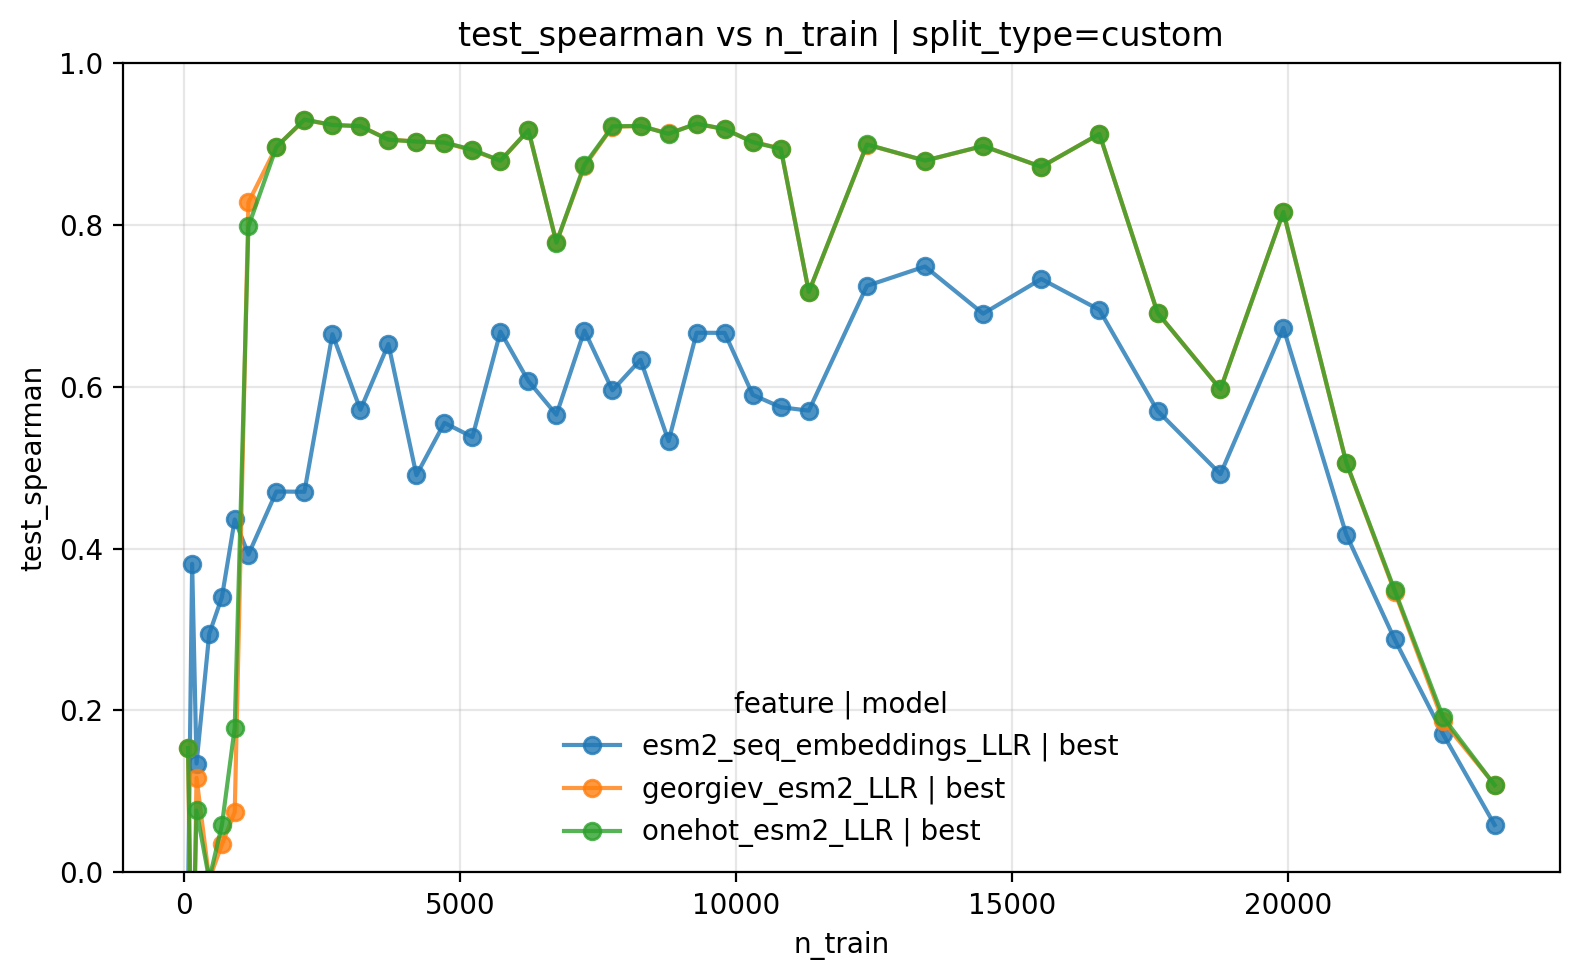

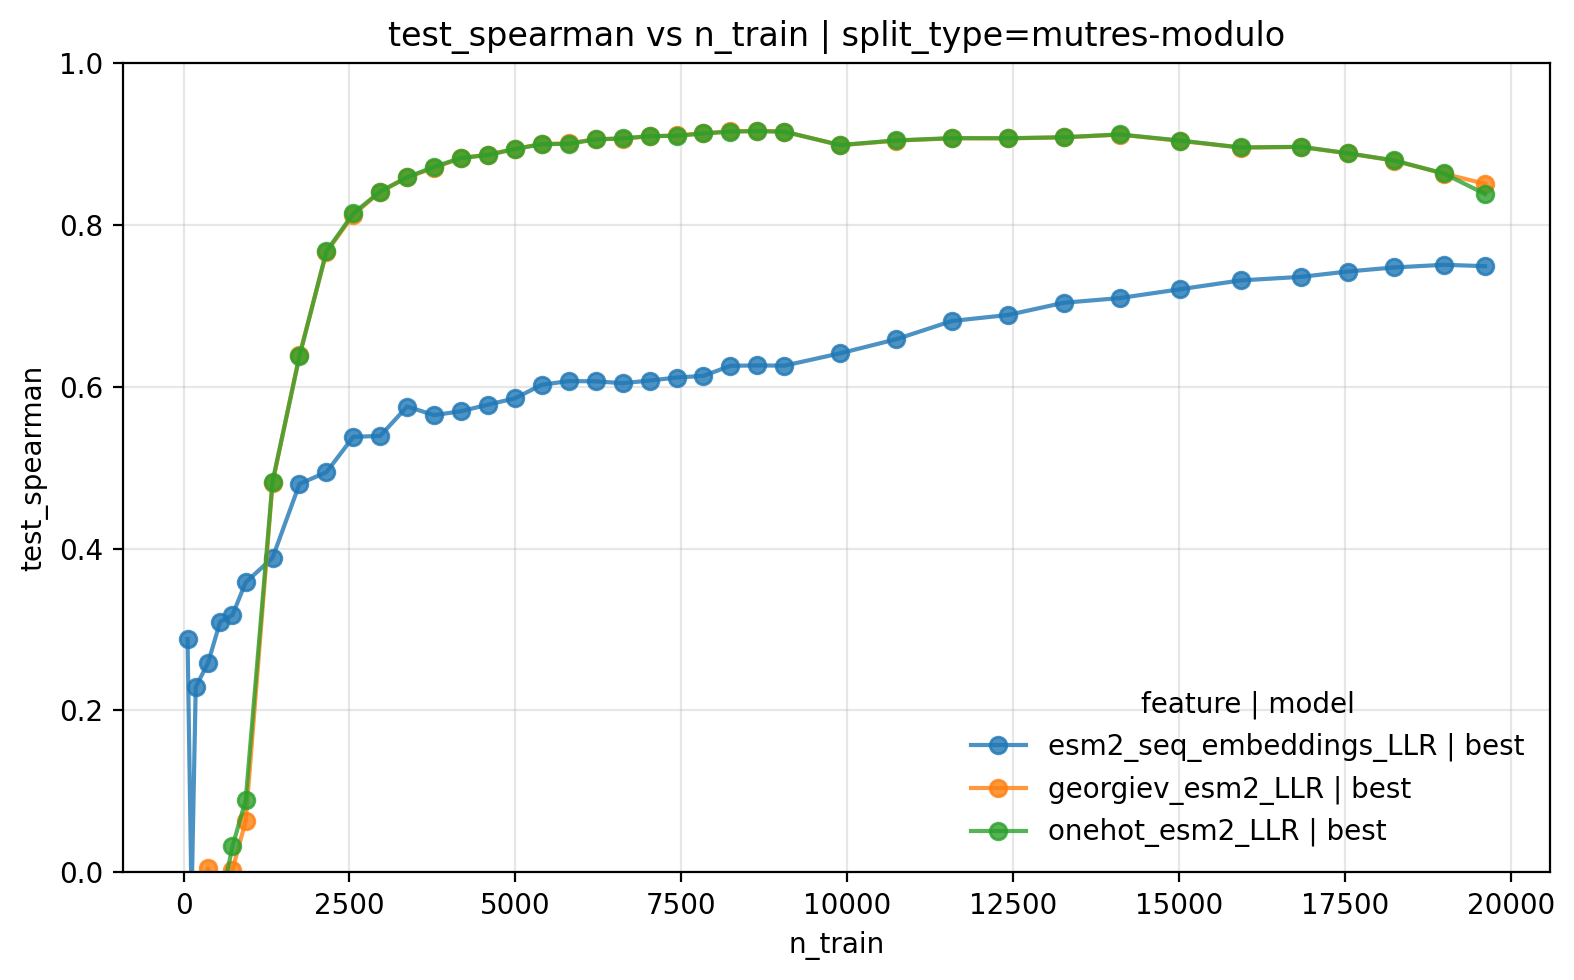

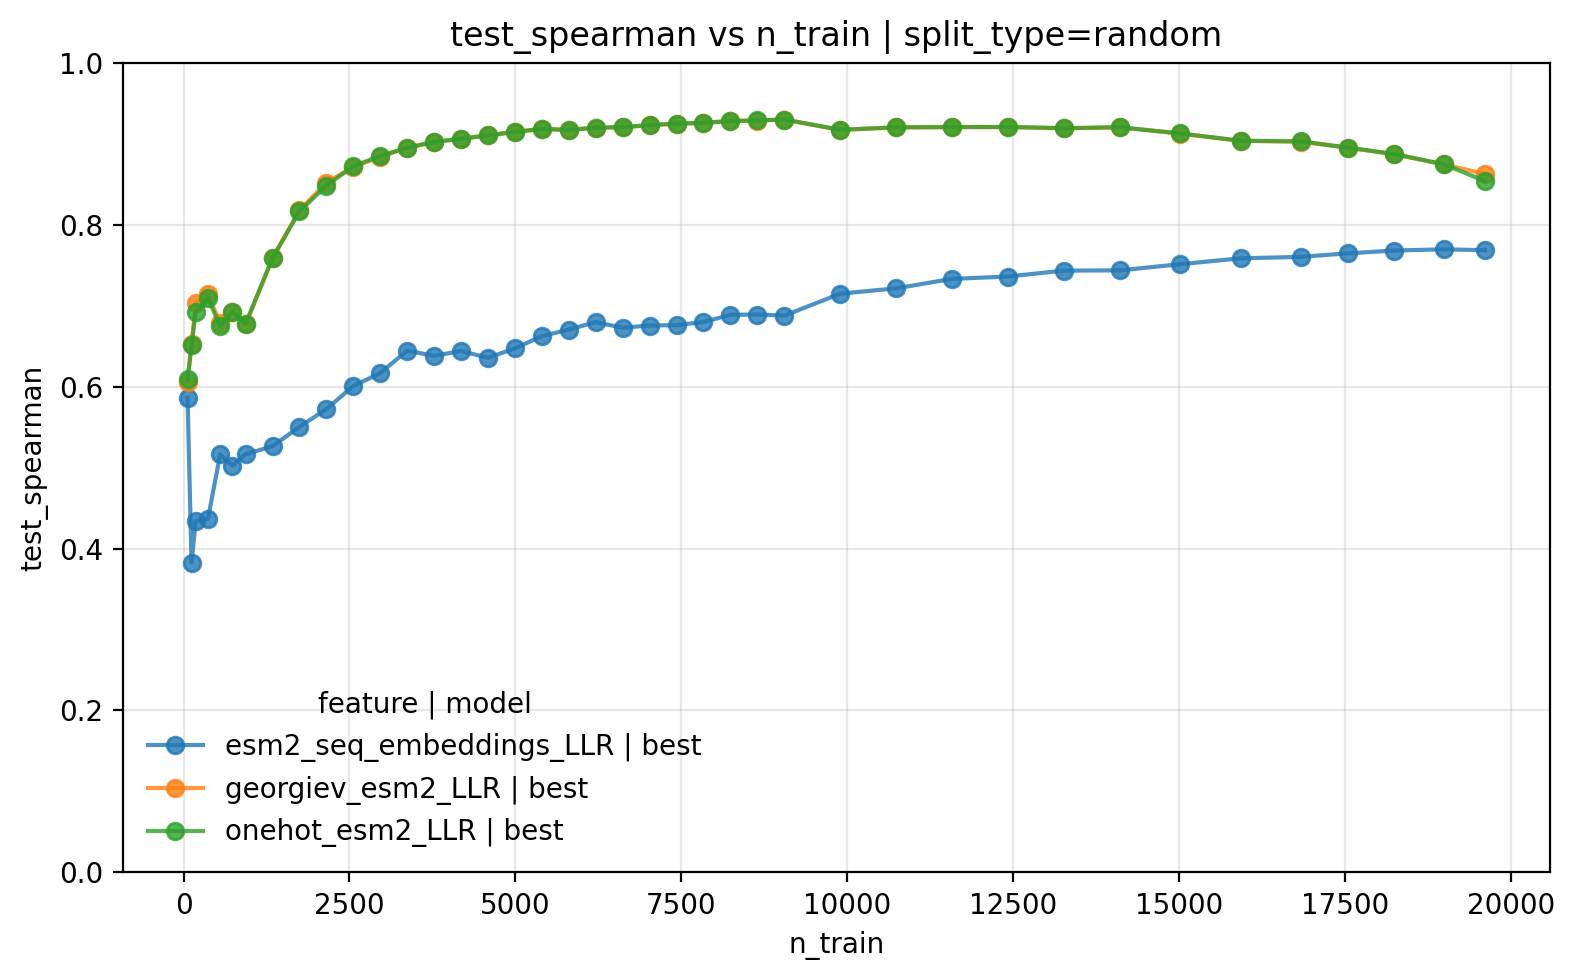

{'figure_paths': ['/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_custom_best.png',
                  '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_mutres-modulo_best.png',
                  '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/data_efficiency_test_spearman_random_best.png'],
 'metric_col_list': ['test_spearman'],
 'n_filtered_rows': 726,
 'n_plot_rows_total': 363,
 'n_summary_rows': 726,
 'plotted_pairs': [{'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 117,
                    'split_type': 'custom'},
                   {'metric_col': 'test_spearman',
                    'n_lines': 3,
                    'n_rows': 123,
                    'split_type': 'mutres-modulo'},
                  

In [8]:
from pprint import pprint

import agentic_protein_design.steps.visualize_ml_results as ml_viz_step

visualize_ml_results = ml_viz_step.visualize_ml_results
default_viz_inputs = ml_viz_step.default_user_inputs

viz_inputs = default_viz_inputs()
viz_inputs['data_fbase'] = user_inputs.get('data_fbase', 'examples')
viz_inputs['data_subfolder'] = user_inputs.get('data_subfolder', '')
viz_inputs['metrics_summary_fname'] = f"{user_inputs['classification_or_regression']}_metrics_summary{user_inputs.get('csv_suffix', '')}.csv"
viz_inputs['model_name_list'] = ['best'] # ['xgboost', 'ridge']
viz_inputs['metric_col'] = ['test_spearman']  # string or list
viz_inputs['target_col_list'] = user_inputs.get('target_col', []) if isinstance(user_inputs.get('target_col', []), list) else [user_inputs.get('target_col')]
viz_inputs['split_type_list'] = []  # [] -> iterate all split types in summary CSV
viz_inputs['feature_label_list'] = list(user_inputs['feature_combinations_dict'].keys())
viz_inputs['save_figure'] = True
viz_inputs['show_figure'] = True
viz_inputs['figure_output_dir'] = ''  # default: summary csv folder
viz_inputs['figure_fname'] = ''       # default auto name
viz_inputs['x_limits'] = [0, None]  # e.g. [0, 10000]; None/[] uses matplotlib defaults
viz_inputs['y_limits'] = [0, 1]      # e.g. [0.0, 1.0]; None/[] uses matplotlib defaults

# Optional override:
viz_inputs['metrics_summary_csv_path'] = '/Users/charmainechia/Documents/projects/MUTAGENESIS-DATA-BENCHMARKS/ml/output/D7PM05_CLYGR_Somermeyer_2022/regression_metrics_summary_merged-0-1.csv'

viz_result = visualize_ml_results(viz_inputs)
pprint(viz_result)
